# Tester_branch에서 최종 모델 성능 확인 진행

In [5]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

df = pd.DataFrame(data=wine.data, columns= wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# DT 모델링 성능

Best Hyper-parameter: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9224137931034484


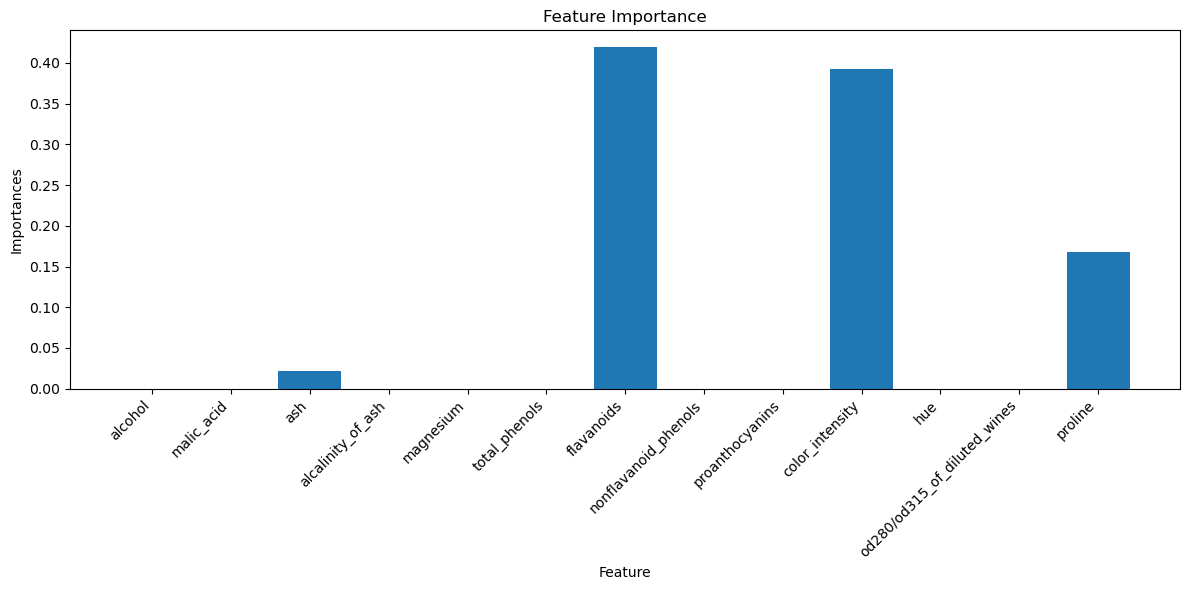

In [6]:
''' 코드를 작성해주세요 '''
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

# 하이퍼파라미터 후보군 설정
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# GridSearchCV 설정 및 학습 실행 (변수 이름 변경: grid_search_dt)
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

# 결과 출력
print(f"Best Hyper-parameter: {grid_search_dt.best_params_}")
print(f"Best Score: {grid_search_dt.best_score_}")

# 변수 중요도 시각화 (최적 모델 변수 이름 변경: best_dt_model)
best_dt_model = grid_search_dt.best_estimator_
importances_dt = best_dt_model.feature_importances_
feature_names = X.columns

# 시각화 설정
plt.figure(figsize=(12, 6))
plt.bar(feature_names, importances_dt)
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9576354679802955


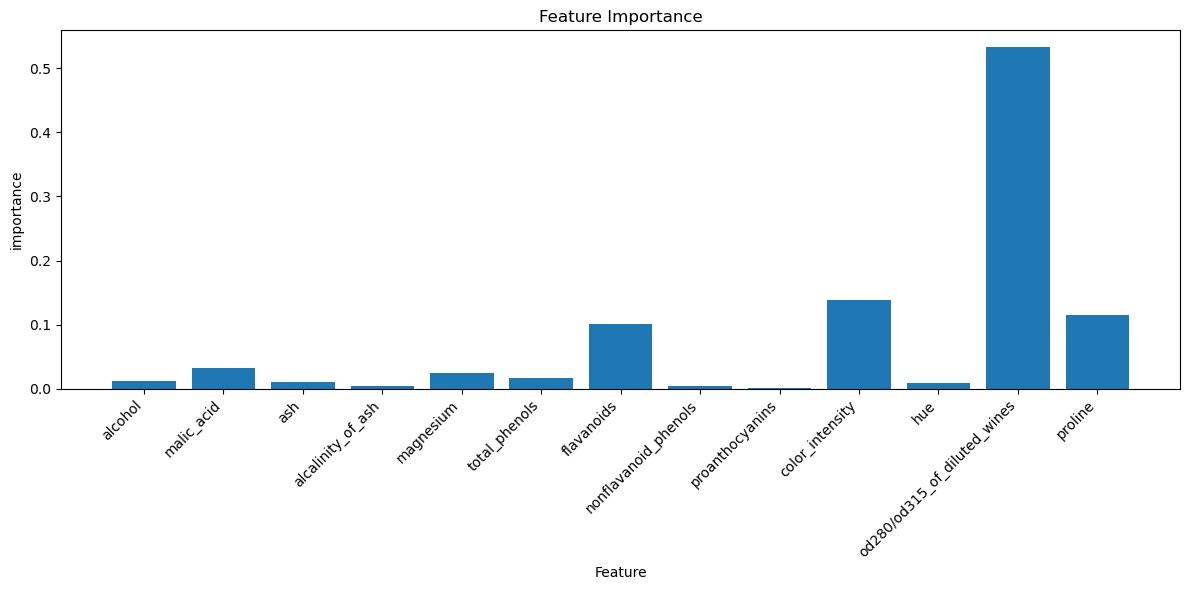

In [7]:
''' 코드를 작성해주세요 '''

from xgboost import XGBClassifier

# XGBoost 분류기 모델 생성
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# 하이퍼파라미터 후보군
param_grid_xgb = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}

# GridSearchCV 설정 및 학습 실행 (변수 이름 변경: grid_search_xgb)
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='accuracy', verbose=0)
grid_search_xgb.fit(X_train, y_train)

# 결과 출력
print(f"Best parameters: {grid_search_xgb.best_params_}")
print(f"Best accuracy: {grid_search_xgb.best_score_}")

# 변수 중요도 시각화 (최적 모델 변수 이름 변경: best_xgb_model)
best_xgb_model = grid_search_xgb.best_estimator_
importances_xgb = best_xgb_model.feature_importances_
feature_names = X.columns

# 시각화 설정
plt.figure(figsize=(12, 6))
plt.bar(feature_names, importances_xgb)
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



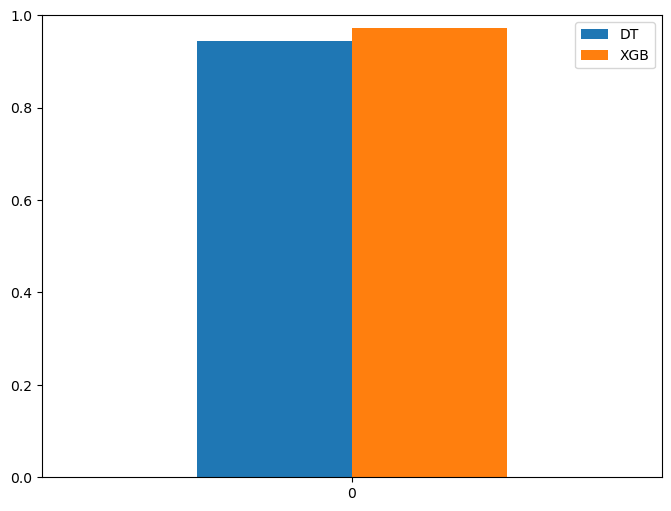

In [8]:
''' 코드를 작성해주세요 '''

from sklearn.metrics import accuracy_score, classification_report

# 각 모델의 테스트 데이터 예측 수행
dt_pred = best_dt_model.predict(X_test)
xgb_pred = best_xgb_model.predict(X_test)

# 각 모델의 정확도 계산
dt_accuracy = accuracy_score(y_test, dt_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# DT 모델 성능 리포트 출력
print("="*20, "DT 성능 확인", "="*20)
print(f"DT accuracy : {dt_accuracy}")
print(classification_report(y_test, dt_pred))

# XGB 모델 성능 리포트 출력
print("="*20, "XGB 성능 확인", "="*20)
print(f"XGB accuracy : {xgb_accuracy}")
print(classification_report(y_test, xgb_pred))


# 두 모델의 정확도 비교 시각화
# DataFrame을 만들어서 bar plot을 그리면 자동으로 범례가 생성됩니다.
accuracy_df = pd.DataFrame(
    {'DT': [dt_accuracy], 'XGB': [xgb_accuracy]},
    index=['accuracy']
)

# kind='bar'를 사용하고, x축 눈금은 보이지 않게 설정합니다.
ax = accuracy_df.plot(kind='bar', figsize=(8, 6), rot=0)
ax.set_xticklabels([0]) # x축의 'accuracy' 라벨을 숨깁니다.
ax.set_xlabel("")      # x축 이름도 비워둡니다.

plt.ylim(0, 1.0)       # y축 범위를 0에서 1로 설정합니다.
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">